In this notebook we perform :
-Load the encoded dataset.
-Identify numerical features.
-Detect outliers using the IQR method.
-Visualize outliers with boxplots.
-Calculate the percentage of outliers.
-Decide whether to keep or treat outliers (without removing them yet, since fraud datasets naturally contain extreme values).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/processed/financial_fraud_encoded.csv")
print("Dataset Shape:", df.shape)
df.head(2)

Dataset Shape: (1000000, 48)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,payment_type_1,payment_type_2,payment_type_3,payment_type_4,employment_status_1,employment_status_2,employment_status_3,employment_status_4,employment_status_5,employment_status_6,housing_status_1,housing_status_2,housing_status_3,housing_status_4,housing_status_5,housing_status_6,source_1,device_os_1,device_os_2,device_os_3,device_os_4
0,0,0.3,0.986506,34.0,25.0,40,0.006735,102.453711,1059,13096.035018,7850.955007,6742.080561,5,5,163.0,1,0,1,9.0,0,1500.0,0,16.224843,1,1.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0.8,0.617426,34.0,89.0,20,0.010095,-0.849551,1658,9223.283431,5745.251481,5941.664859,3,18,154.0,1,1,1,2.0,0,1500.0,0,3.363854,1,1.0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [4]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Total Numerical Features:", len(numerical_cols))
print(numerical_cols)

Total Numerical Features: 48
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month', 'payment_type_1', 'payment_type_2', 'payment_type_3', 'payment_type_4', 'employment_status_1', 'employment_status_2', 'employment_status_3', 'employment_status_4', 'employment_status_5', 'employment_status_6', 'housing_status_1', 'housing_status_2', 'housing_status_3', 'housing_status_4', 'housing_status_5', 'housing_status_6', 'source_1', 'device_os_1', 'device_os_2', 'device_os_3', 'device_os_4

In [5]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,41.670768,36.146230,5.000000e+00,34.000000,34.000000,34.000000,383.000000
current_address_months_count,1000000.0,86.817583,88.248728,0.000000e+00,20.000000,53.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [6]:
outlier_summary = []     #detecting outliers using IQR method 
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({"Feature": col,"Outliers": outliers,
        "Percentage": round((outliers / len(df)) * 100, 2)})
outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Outliers,Percentage
0,fraud_bool,11029,1.10
1,income,0,0.00
2,name_email_similarity,0,0.00
3,prev_address_months_count,282958,28.30
4,current_address_months_count,41493,4.15
5,customer_age,1373,0.14
6,days_since_request,94834,9.48
7,intended_balcon_amount,222702,22.27
8,zip_count_4w,59871,5.99
9,velocity_6h,9005,0.90


In [7]:
outlier_df.sort_values(by="Outliers",ascending=False) #Sort by Number of Outliers

,Feature,Outliers,Percentage
3,prev_address_months_count,282958,28.30
20,proposed_credit_limit,241742,24.17
19,has_other_cards,222988,22.30
7,intended_balcon_amount,222702,22.27
12,bank_branch_count_8w,175243,17.52
40,housing_status_4,169135,16.91
31,employment_status_1,138288,13.83
29,payment_type_3,118837,11.88
17,phone_mobile_valid,110324,11.03
6,days_since_request,94834,9.48


In [8]:
#Features Having Outliers
outlier_df[outlier_df["Outliers"] > 0]

,Feature,Outliers,Percentage
0,fraud_bool,11029,1.10
3,prev_address_months_count,282958,28.30
4,current_address_months_count,41493,4.15
5,customer_age,1373,0.14
6,days_since_request,94834,9.48
7,intended_balcon_amount,222702,22.27
8,zip_count_4w,59871,5.99
9,velocity_6h,9005,0.90
10,velocity_24h,2917,0.29
12,bank_branch_count_8w,175243,17.52


C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


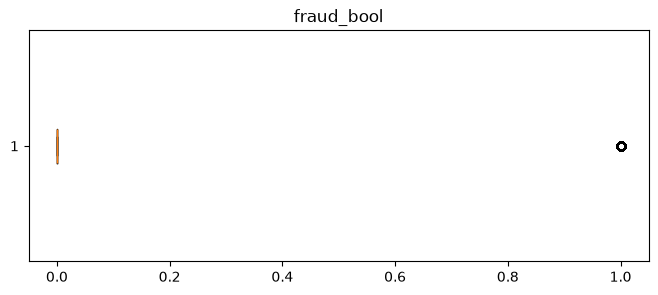

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


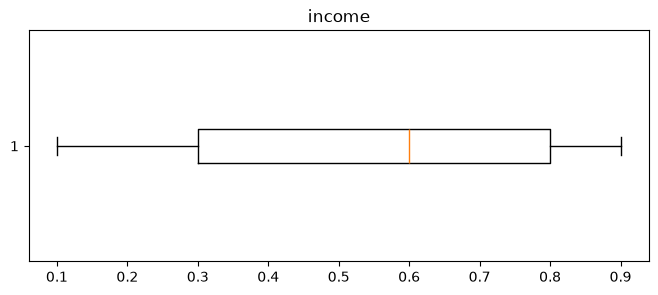

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


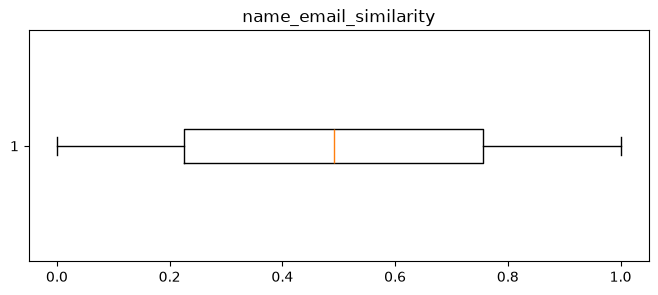

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


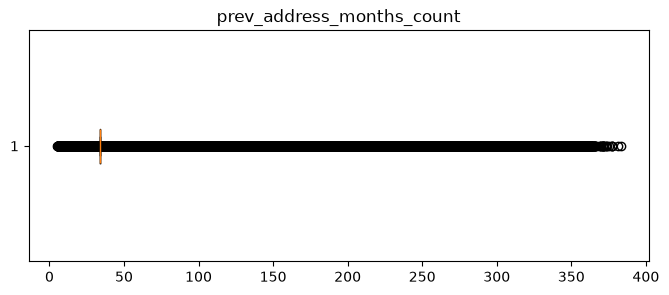

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


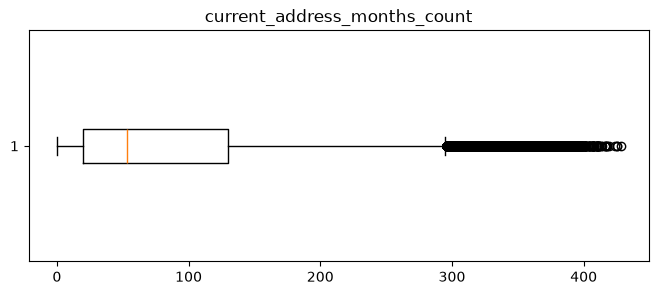

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


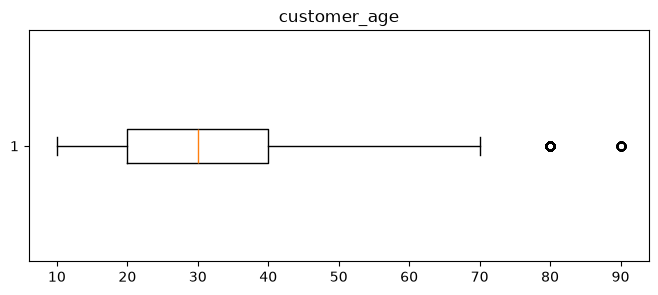

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


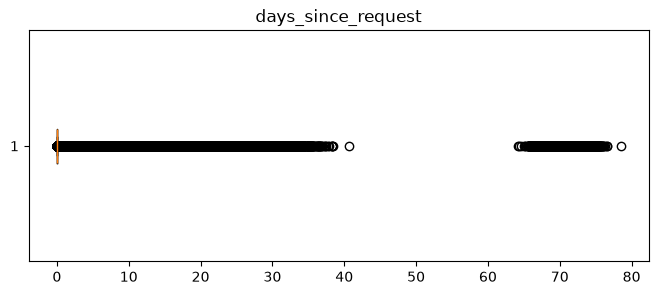

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


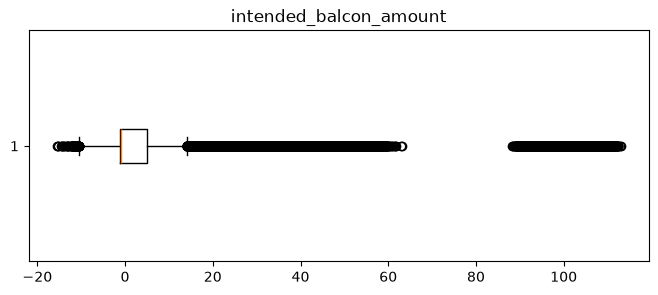

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


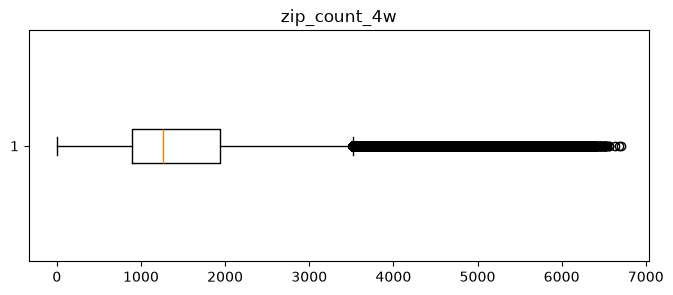

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


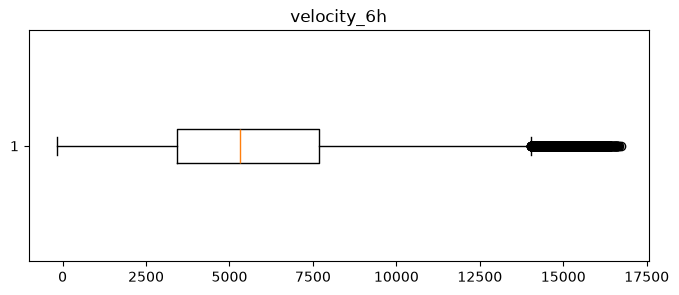

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


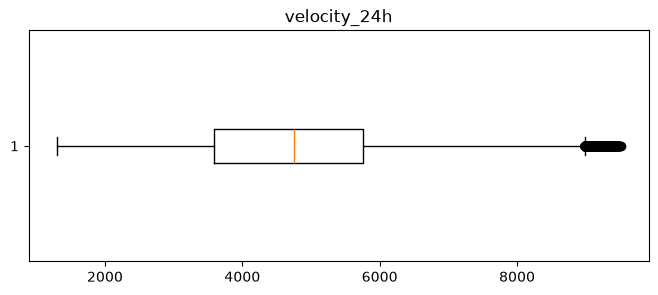

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


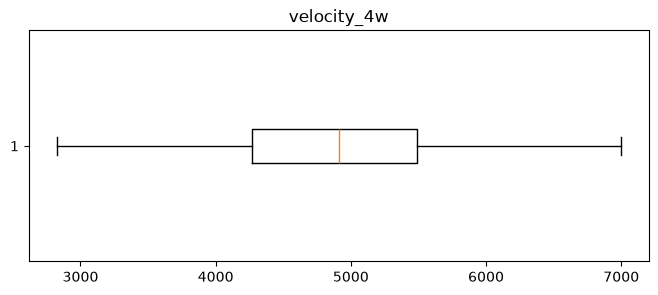

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


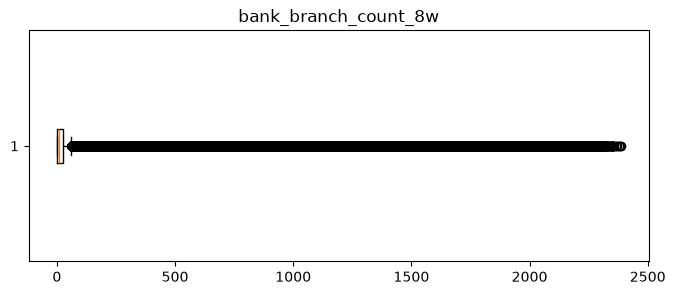

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


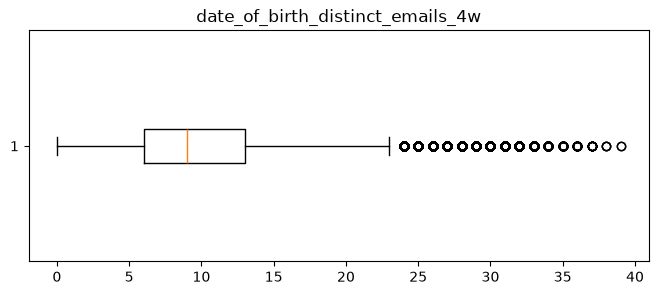

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


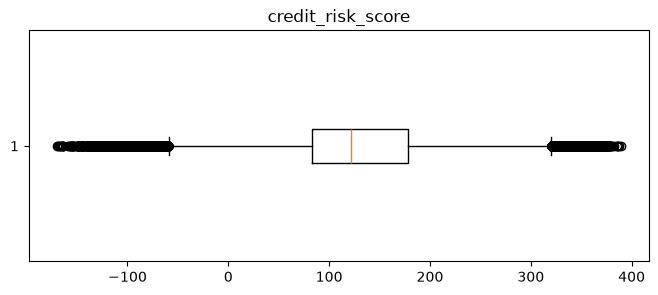

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


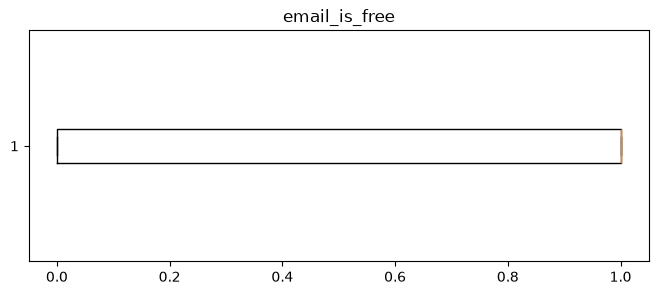

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


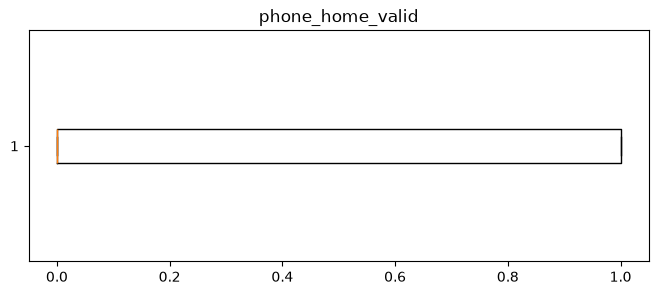

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


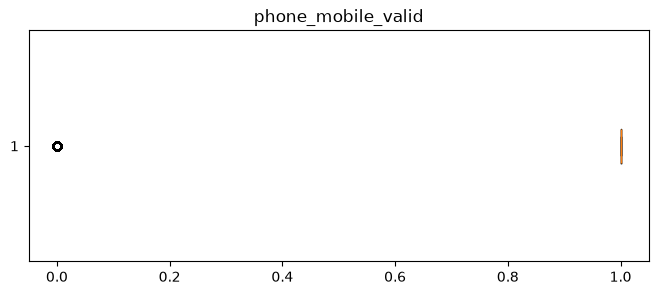

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


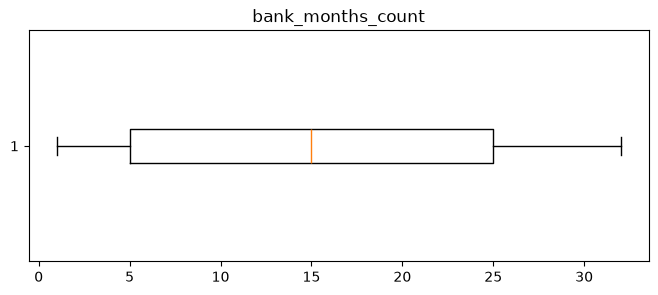

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


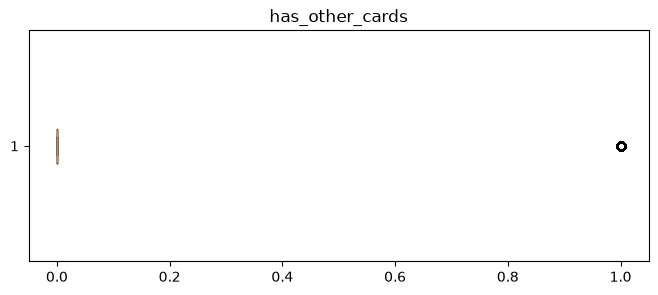

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


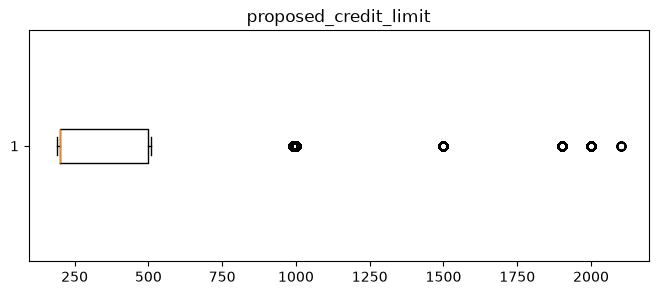

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


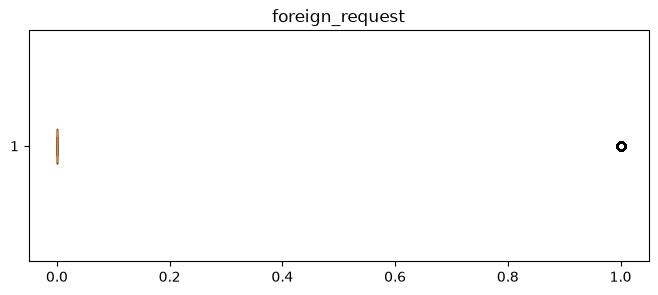

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


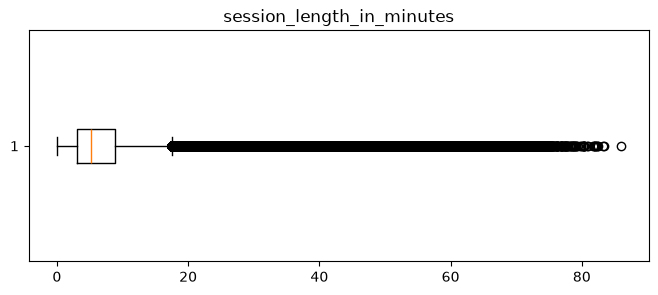

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


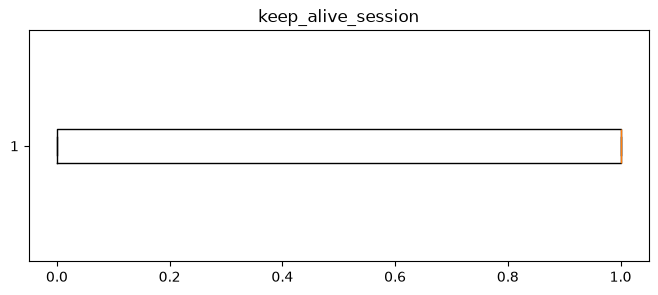

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


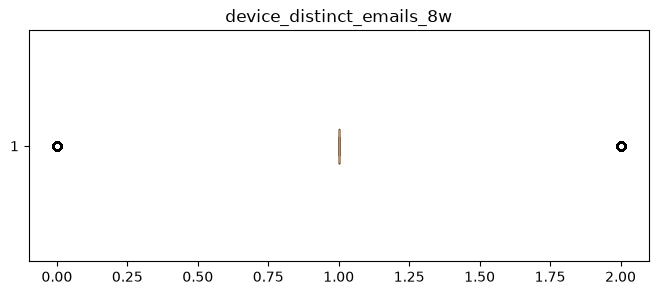

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


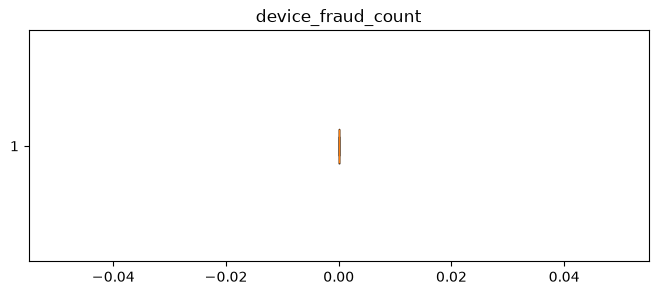

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


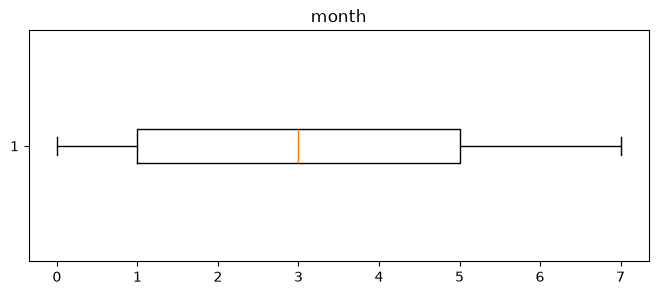

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


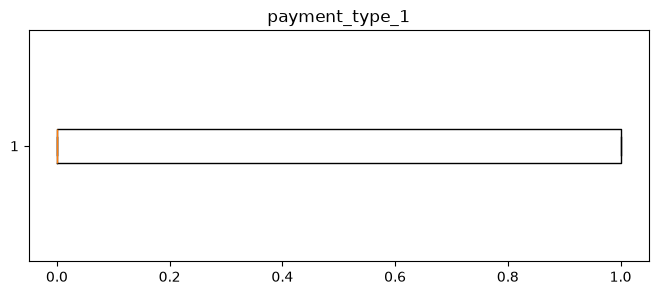

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


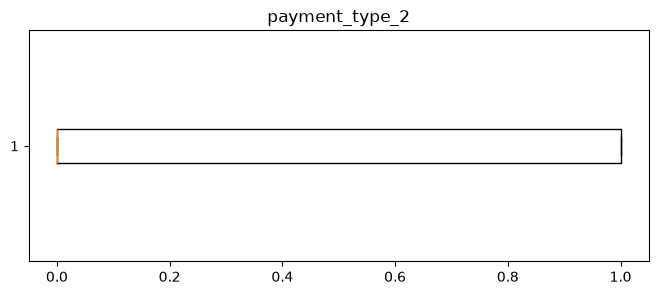

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


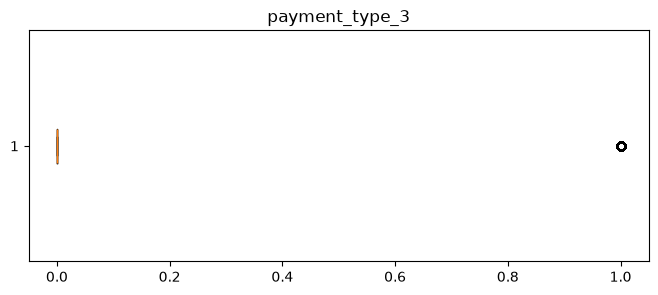

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


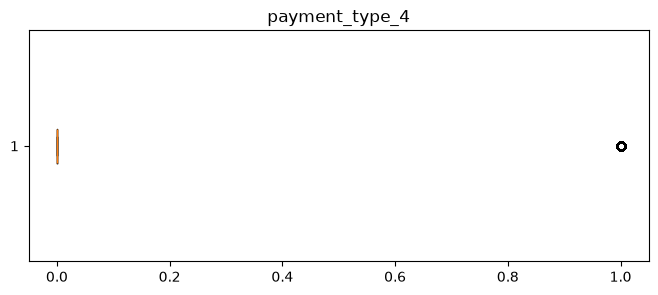

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


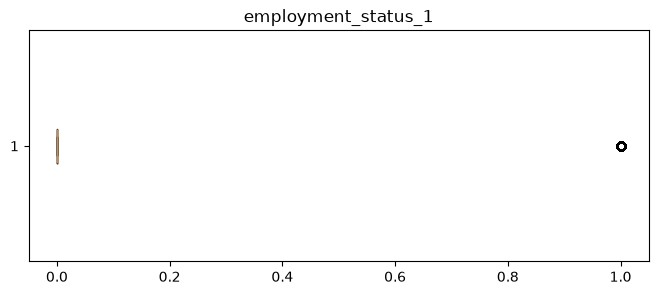

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


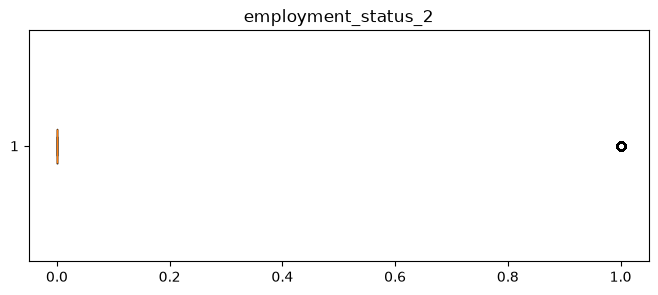

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


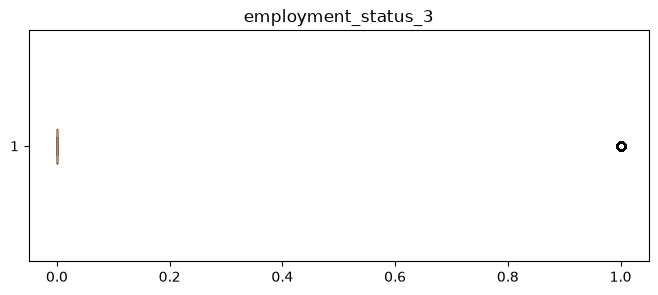

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


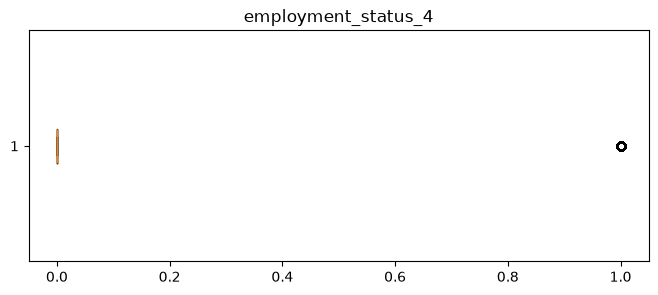

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


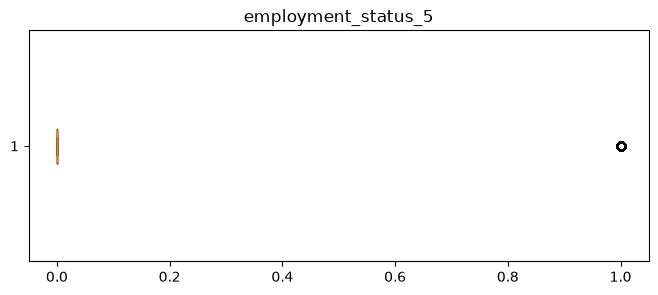

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


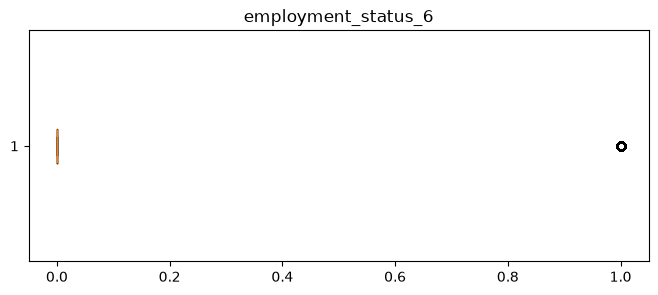

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


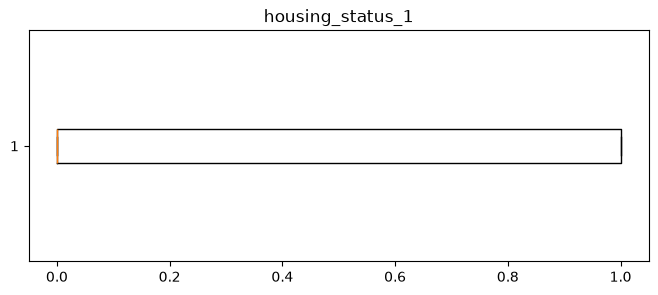

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


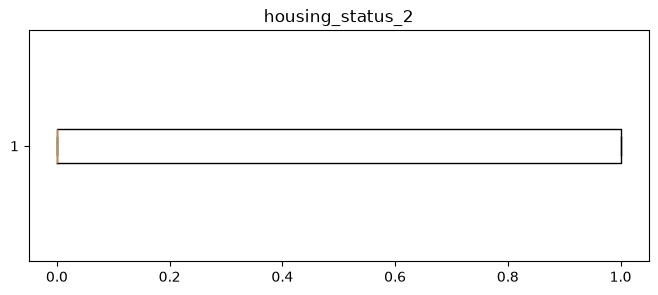

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


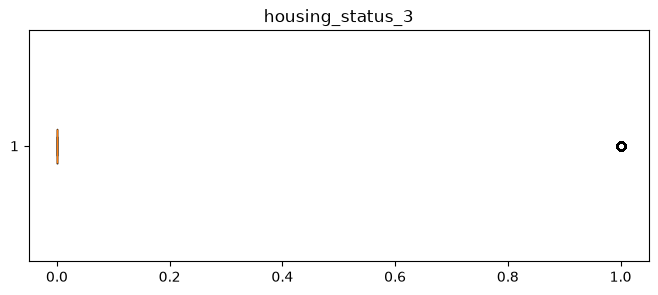

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


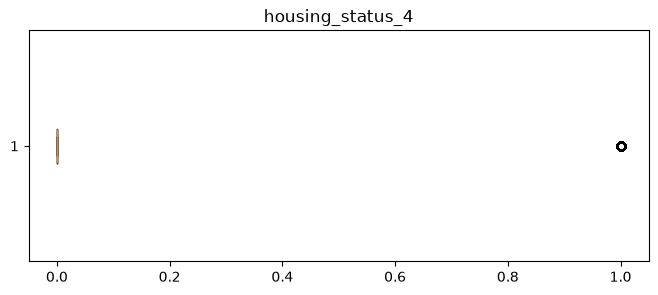

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


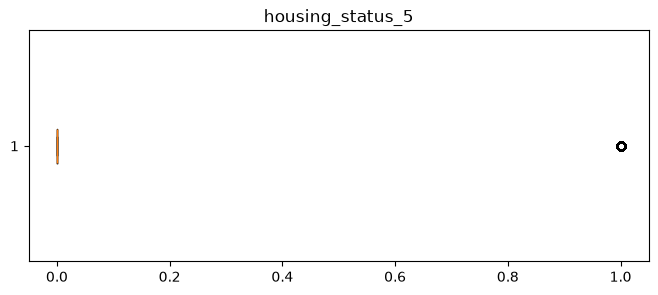

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


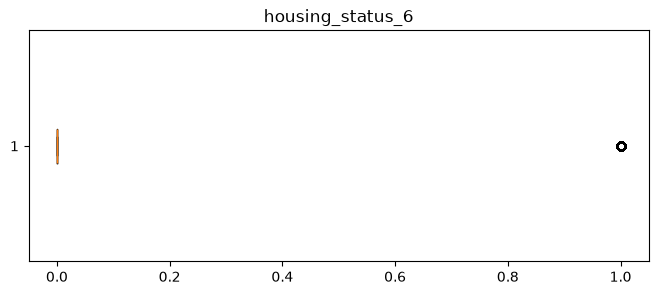

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


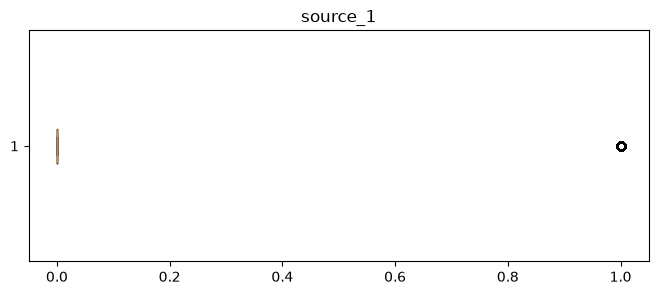

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


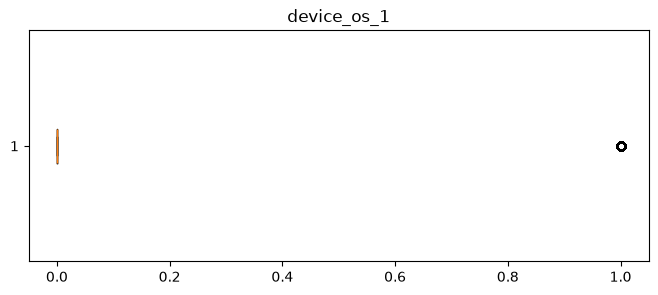

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


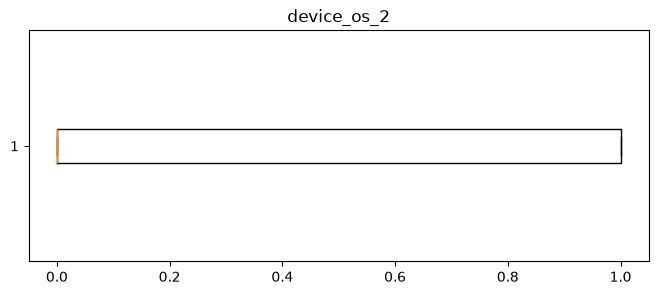

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


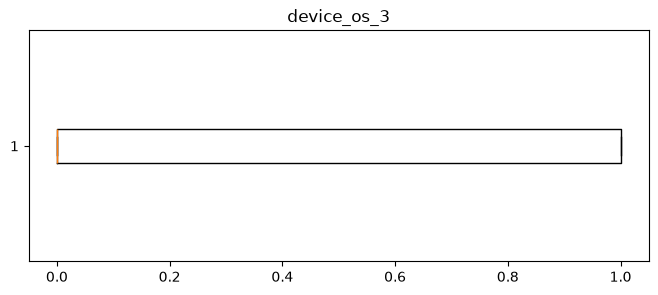

C:\Users\dell\AppData\Local\Temp\ipykernel_10108\2457000168.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


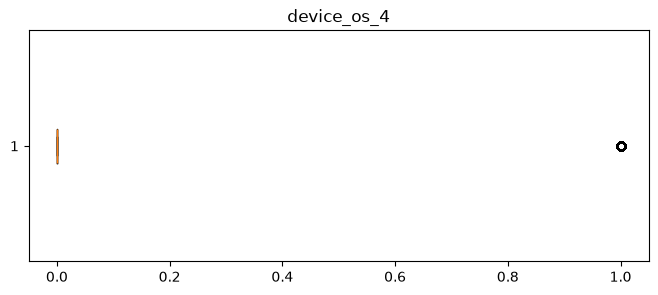

In [9]:
for col in numerical_cols:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

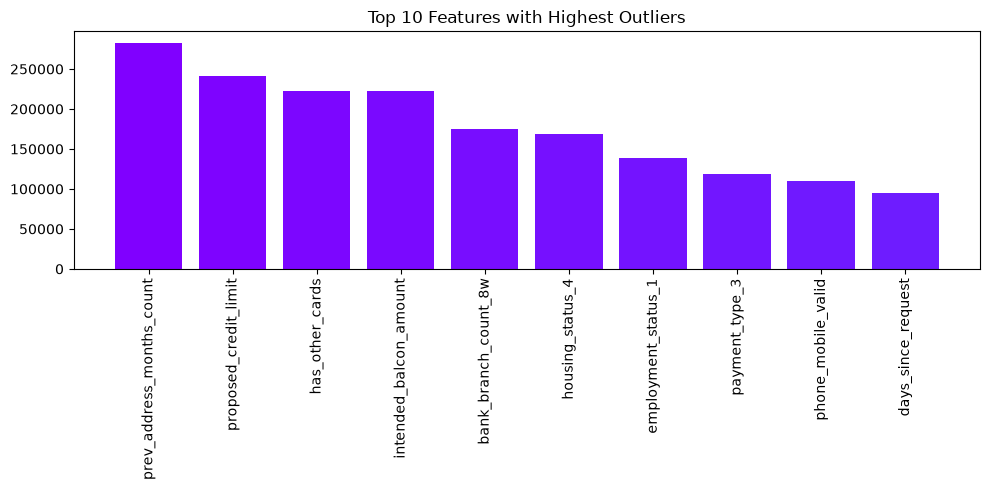

In [13]:
#Visualize Top 10 Outlier Features
top10 = outlier_df.sort_values(by="Outliers", ascending=False).head(10)
plt.figure(figsize=(10, 5))
colors = plt.cm.rainbow(range(len(top10)))
plt.bar(top10["Feature"], top10["Outliers"], color=colors)
plt.xticks(rotation=90)
plt.title("Top 10 Features with Highest Outliers")
plt.tight_layout()
plt.show()


In [14]:
#Check Infinite Values
np.isinf(df).sum().sum()

np.int64(0)

In [15]:
outlier_df.to_csv("../data/processed/outlier_summary.csv",index=False)
print("Outlier report saved successfully.")

Outlier report saved successfully.


# Summary

- Loaded the encoded dataset.
- Identified all numerical features.
- Generated descriptive statistics.
- Detected outliers using the Interquartile Range (IQR) method.
- Calculated the number and percentage of outliers for each feature.
- Visualized outliers using boxplots.
- Identified the top features containing the highest number of outliers.
- Verified that no infinite values were present.
- Saved the outlier analysis report for future reference.

### Note

Since fraud detection datasets naturally contain extreme values that may represent fraudulent behavior, outliers were **identified but not removed**. The results of this analysis will help guide future feature engineering and model development.